In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW

def cnn1d_gru_model(input_shape, num_classes):
    model = Sequential()

    # CNN Block 1
    model.add(Conv1D(64, kernel_size=5, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    # CNN Block 2
    model.add(Conv1D(128, kernel_size=5, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.35))

    # CNN Block 3
    model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.35))

    # GRU Layer with recurrent dropout
    model.add(GRU(128, return_sequences=False, recurrent_dropout=0.2))
    model.add(Dropout(0.4))

    # Dense layers
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-3)))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model


# Per Frame

## Ref: Mouth

In [2]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\mouth"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [3]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)




Epoch 1/200


280/280 [==============================] - 6s 11ms/step - loss: 2.5663 - accuracy: 0.2821 - val_loss: 1.7122 - val_accuracy: 0.6116 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 2s 9ms/step - loss: 1.7578 - accuracy: 0.5551 - val_loss: 1.3048 - val_accuracy: 0.7054 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 3s 9ms/step - loss: 1.4489 - accuracy: 0.6578 - val_loss: 1.1697 - val_accuracy: 0.7446 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 3s 9ms/step - loss: 1.2409 - accuracy: 0.7411 - val_loss: 0.9585 - val_accuracy: 0.8348 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 2s 9ms/step - loss: 1.1180 - accuracy: 0.7786 - val_loss: 0.9285 - val_accuracy: 0.8179 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 2s 9ms/step - loss: 1.0101 - accuracy: 0.8083 - val_loss: 0.7636 - val_accuracy: 0.8839 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 2s 9

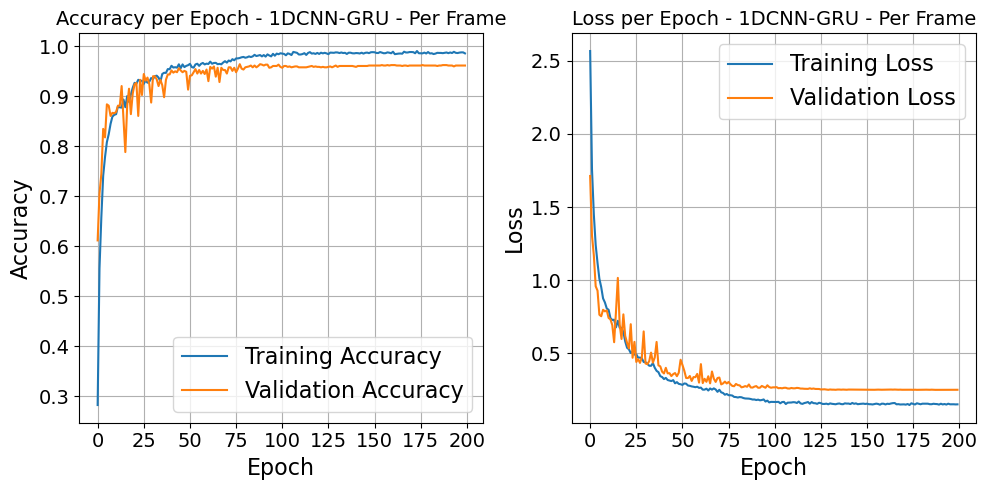

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'mouth'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'mouth'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-vec.png"))
plt.show()

## Ref: Nose

In [5]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\nose"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [6]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 8s 13ms/step - loss: 2.6076 - accuracy: 0.2904 - val_loss: 2.7060 - val_accuracy: 0.3321 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 4s 14ms/step - loss: 1.7494 - accuracy: 0.5815 - val_loss: 1.3805 - val_accuracy: 0.6902 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 4s 15ms/step - loss: 1.3444 - accuracy: 0.7205 - val_loss: 1.2348 - val_accuracy: 0.7527 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 4s 14ms/step - loss: 1.1685 - accuracy: 0.7739 - val_loss: 0.9736 - val_accuracy: 0.8321 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 5s 19ms/step - loss: 1.0610 - accuracy: 0.8092 - val_loss: 0.9004 - val_accuracy: 0.8473 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 5s 19ms/step - loss: 0.9654 - accuracy: 0.8279 - val_loss: 1.2151 - val_accuracy: 0.7634 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s 

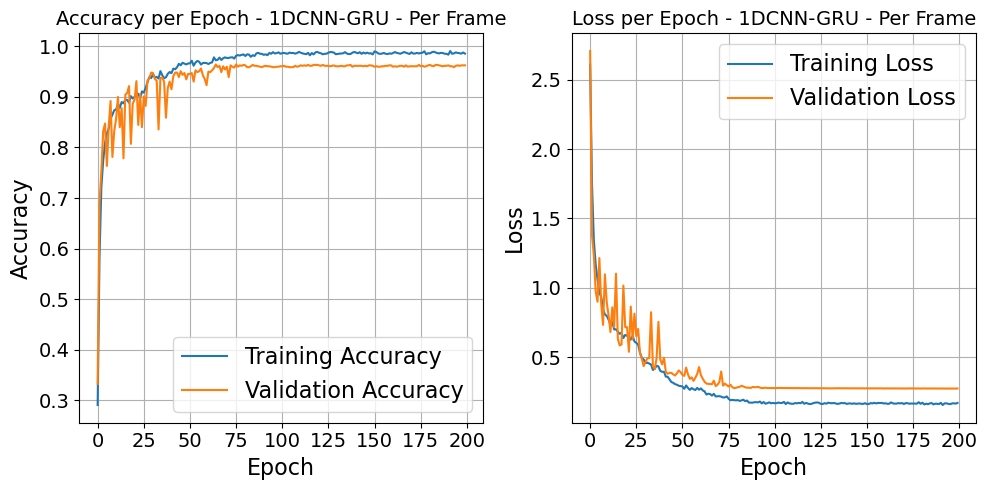

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'nose'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'nose'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-vec.png"))
plt.show()

## Ref: Chin

In [8]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\chin"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [9]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 10s 16ms/step - loss: 2.6953 - accuracy: 0.2596 - val_loss: 2.5531 - val_accuracy: 0.3259 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 3s 12ms/step - loss: 1.9096 - accuracy: 0.5069 - val_loss: 1.6587 - val_accuracy: 0.5857 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 4s 14ms/step - loss: 1.5508 - accuracy: 0.6326 - val_loss: 1.2146 - val_accuracy: 0.7616 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 6s 21ms/step - loss: 1.3538 - accuracy: 0.7067 - val_loss: 1.0811 - val_accuracy: 0.7723 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 6s 21ms/step - loss: 1.1955 - accuracy: 0.7487 - val_loss: 1.1280 - val_accuracy: 0.7705 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 6s 21ms/step - loss: 1.0922 - accuracy: 0.7835 - val_loss: 1.1778 - val_accuracy: 0.7393 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

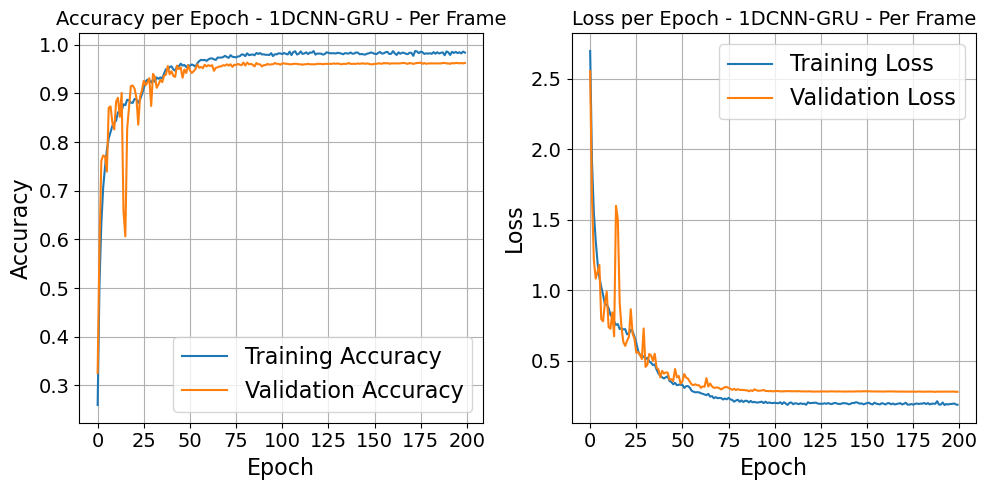

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'chin'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'chin'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-vec.png"))
plt.show()

# Delta Frame

## Ref: Mouth

In [11]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\mouth"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [12]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 11s 23ms/step - loss: 2.9996 - accuracy: 0.1545 - val_loss: 2.2923 - val_accuracy: 0.3991 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 5s 19ms/step - loss: 2.2996 - accuracy: 0.3833 - val_loss: 1.5385 - val_accuracy: 0.6438 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 5s 18ms/step - loss: 1.7524 - accuracy: 0.5721 - val_loss: 1.1905 - val_accuracy: 0.7598 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 5s 17ms/step - loss: 1.4579 - accuracy: 0.6763 - val_loss: 1.0562 - val_accuracy: 0.8080 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 5s 19ms/step - loss: 1.3079 - accuracy: 0.7239 - val_loss: 0.9163 - val_accuracy: 0.8545 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 5s 18ms/step - loss: 1.1471 - accuracy: 0.7699 - val_loss: 0.8462 - val_accuracy: 0.8830 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 5s

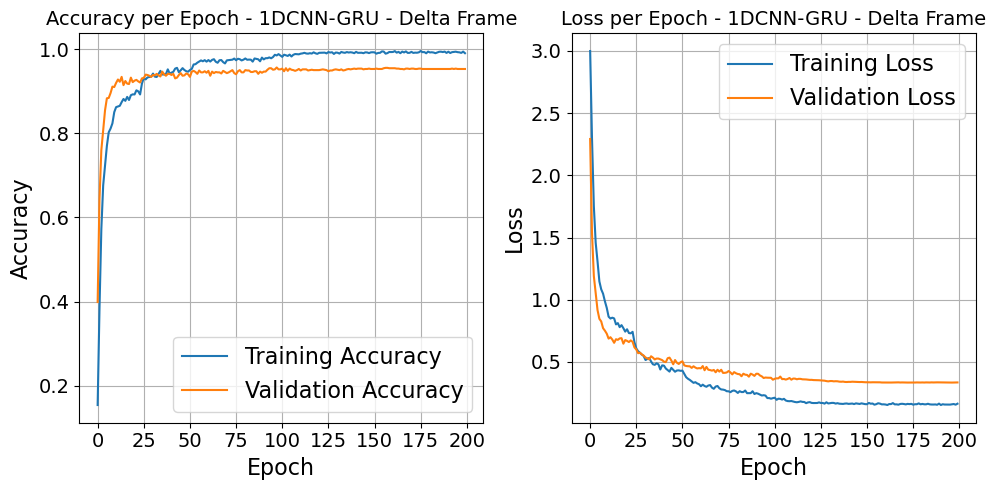

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'mouth'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'mouth'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-del.png"))
plt.show()

## Ref: Nose

In [14]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\nose"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 6s 13ms/step - loss: 3.0544 - accuracy: 0.1424 - val_loss: 2.5207 - val_accuracy: 0.2920 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 3s 12ms/step - loss: 2.4199 - accuracy: 0.3480 - val_loss: 1.6007 - val_accuracy: 0.6589 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 3s 12ms/step - loss: 1.7781 - accuracy: 0.5743 - val_loss: 1.1737 - val_accuracy: 0.7670 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 3s 12ms/step - loss: 1.4499 - accuracy: 0.6839 - val_loss: 1.0177 - val_accuracy: 0.8232 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 3s 12ms/step - loss: 1.2615 - accuracy: 0.7431 - val_loss: 0.9272 - val_accuracy: 0.8589 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 3s 12ms/step - loss: 1.1535 - accuracy: 0.7826 - val_loss: 0.8562 - val_accuracy: 0.8625 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 4s 

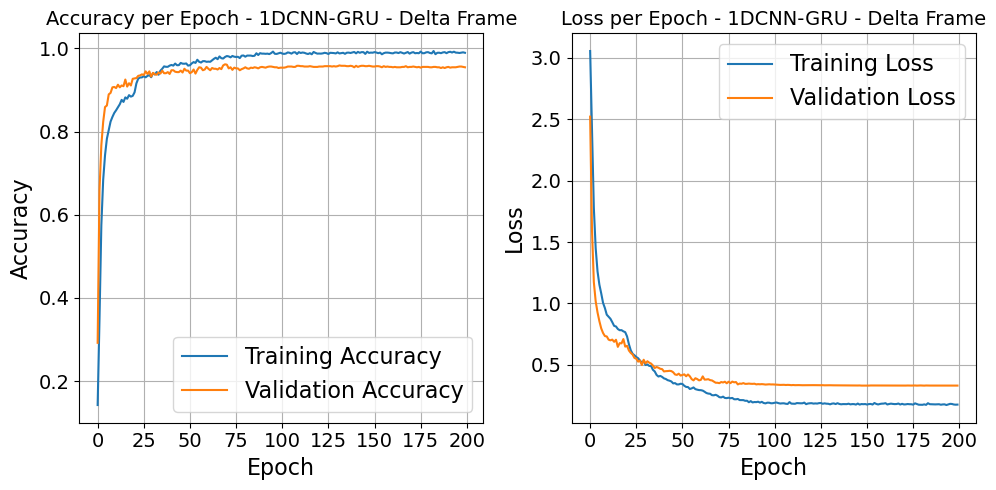

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'nose'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'nose'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-del.png"))
plt.show()

## Ref: Chin

In [17]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\chin"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [18]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 9s 17ms/step - loss: 3.1220 - accuracy: 0.1105 - val_loss: 2.6907 - val_accuracy: 0.2741 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 4s 14ms/step - loss: 2.6081 - accuracy: 0.2792 - val_loss: 1.8964 - val_accuracy: 0.5473 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 4s 14ms/step - loss: 2.0610 - accuracy: 0.4600 - val_loss: 1.4649 - val_accuracy: 0.6804 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 4s 14ms/step - loss: 1.7257 - accuracy: 0.5839 - val_loss: 1.2643 - val_accuracy: 0.7366 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 4s 15ms/step - loss: 1.5150 - accuracy: 0.6417 - val_loss: 1.1036 - val_accuracy: 0.7795 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 4s 15ms/step - loss: 1.3861 - accuracy: 0.6913 - val_loss: 1.0420 - val_accuracy: 0.8036 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 4s 

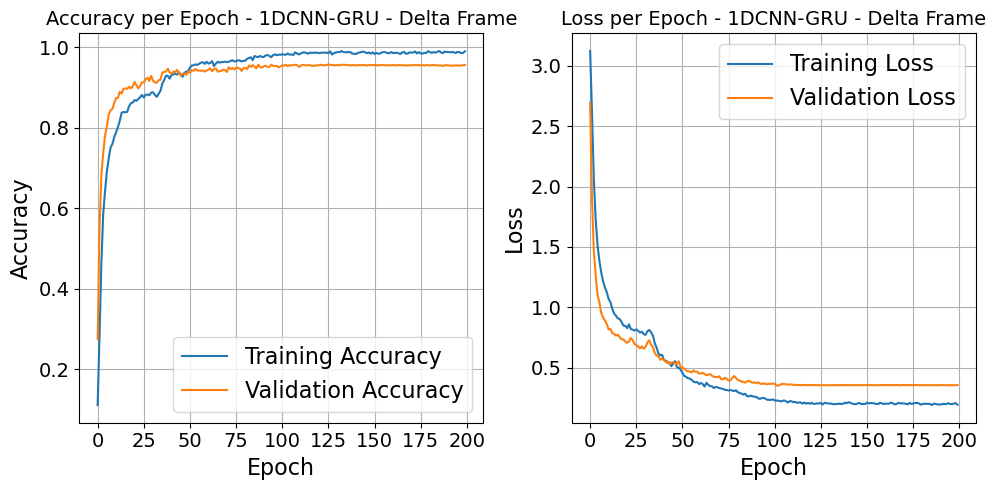

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_gru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-GRU"
titik_ref = 'chin'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'chin'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-GRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-gru_model-all-del.png"))
plt.show()